In [1]:
import pandas
from dataset import BraindumpDataset, split_dataset
from tokenizer import Tokenizer
import torch
%load_ext autoreload
%autoreload 2

In [2]:
df = pandas.read_csv("dataset_5000.csv")
df.head(10)

,input_text,target_text
0,Schedule a meeting with Sarah by Friday and re...,1. Schedule meeting with Sarah by Friday | 2. ...
1,"Don't let me forget to buy protein powder, it'...",1. Buy protein powder | 2. water the plants
2,"Don't let me forget to buy a new keyboard, it'...",1. Buy a new keyboard | 2. pick up dry cleaning
3,"Gotta run the database backup, pick up dry cle...",1. run the database backup | 2. pick up dry cl...
4,Schedule a meeting with the client at midnight...,1. Schedule meeting with the client at midnigh...
5,Remind me to clean the bathroom and I also hav...,1. clean the bathroom | 2. deploy the containe...
6,Remind me to wash the car and I also have to f...,1. wash the car | 2. fix the UI bug by Friday
7,Schedule a meeting with Alex by Friday and rem...,1. Schedule meeting with Alex by Friday | 2. f...
8,"Don't let me forget to buy HDMI cable, it's ur...",1. Buy HDMI cable | 2. take out the trash
9,"I need to buy a new keyboard this weekend, oh ...",1. Buy a new keyboard | 2. Tell mom to finish ...


In [3]:
all_text = " ".join(df['input_text'].astype(str).tolist() + df['target_text'].astype(str).tolist())
tokenizer = Tokenizer(all_text)

In [4]:
for input_text, target_text in zip(df['input_text'], df['target_text']):
    input_ids = tokenizer.encode(input_text)
    target_ids = tokenizer.encode(target_text)
    inputs_words = tokenizer.decode(input_ids)
    print(f"Input IDs: {input_ids}")
    print(f"Target IDs: {target_ids}")
    print(f"Input words: {inputs_words}")
    break
    

Input IDs: [78, 8, 54, 100, 77, 21, 42, 11, 70, 88, 75, 84, 29, 14, 3]
Target IDs: [4, 3, 78, 54, 100, 77, 21, 42, 101, 5, 3, 75, 84, 29, 14]
Input words: schedule a meeting with sarah by friday and remember to run the database backup.


In [5]:
def encode_row(text):
    return tokenizer.encode(text)

df['input_ids'] = df['input_text'].apply(encode_row)
df['target_ids'] = df['target_text'].apply(encode_row)
dataset = BraindumpDataset(df)


In [6]:
tokenizer.decode(df['input_ids'][2]), df['input_text'][2]

("don' t let me forget to buy a new keyboard, it' s urgent! and pick up dry cleaning.",
 "Don't let me forget to buy a new keyboard, it's urgent! And pick up dry cleaning.")

In [7]:
tokenizer.decode(df['target_ids'][2]), df['target_text'][2]

('1. buy a new keyboard | 2. pick up dry cleaning',
 '1. Buy a new keyboard | 2. pick up dry cleaning')

In [8]:
#Need to Add Padding becuase there is a difference in Sequence Lenght input vs label
print(len(dataset[1][0]), len(dataset[1][1]))

21 11


In [9]:
train_dataset, val_dataset, test_dataset = split_dataset(dataset, 32)

In [10]:
trainer_loader = iter(train_dataset)
batch_trainer = next(trainer_loader)
[len(i) for i in batch_trainer['tokenized_input']][0], [len(i) for i in batch_trainer['label']][0]

(22, 19)

In [11]:
validation_loader = iter(val_dataset)
batch2 = next(validation_loader)
[len(i) for i in batch2['tokenized_input']][0], [len(i) for i in batch2['label']][0]

(22, 19)

In [12]:
test_loader = iter(test_dataset)
batch_test = next(test_loader)
[len(i) for i in batch_test['tokenized_input']][0], [len(i) for i in batch_test['label']][0]

(23, 20)

## Training the Model Seq2Seq

In [13]:
from models.seq2seq_attention import EncoderAttention, DecoderAttention, Attention, Seq2SeqAttention
import torch.nn as nn
import torch.optim as optim
from utils import init_weights_attention, plot_weights_initialization, count_parameters_model
import tqdm as notebook_tqdm
import tqdm
import numpy as np

In [14]:
input_dim = tokenizer.get_vocab_size()
output_dim = tokenizer.get_vocab_size()
assert input_dim == output_dim, "Encoder and Decoder must have the same vocabulary size because they share the same tokenizer"

encoder_embedding_dim = 128
decoder_embedding_dim = 128

encoder_hidden_dim = 312
decoder_hidden_dim = 312


encoder_dropout = 0.4
decoder_dropout = 0.4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

attention = Attention(encoder_hidden_dim=encoder_hidden_dim, decoder_hidden_dim=decoder_hidden_dim)

encoder = EncoderAttention(
    input_dim=input_dim,
    embedding_dim=encoder_embedding_dim,
    encoder_hidden_dim=encoder_hidden_dim,
    decoder_hidden_dim=decoder_hidden_dim,
    dropout=encoder_dropout
)

decoder = DecoderAttention(
    output_dim=output_dim,
    embedding_dim=decoder_embedding_dim,
    encoder_hidden_dim=encoder_hidden_dim,
    decoder_hidden_dim=decoder_hidden_dim,
    dropout=decoder_dropout,
    attention=attention
)

Seq2Seq_model_Attention = Seq2SeqAttention(
    encoder=encoder,
    decoder=decoder,
    device=device
)

### Weight initialization

In the paper the state the initialization of the weights are transformed in the Uniform/Gaussian distribution so the weights doesnt explode with the the tahn, making the gradients doesnt have Vanish Gradient

and with the biases are converted to zero, so it updates with the weights


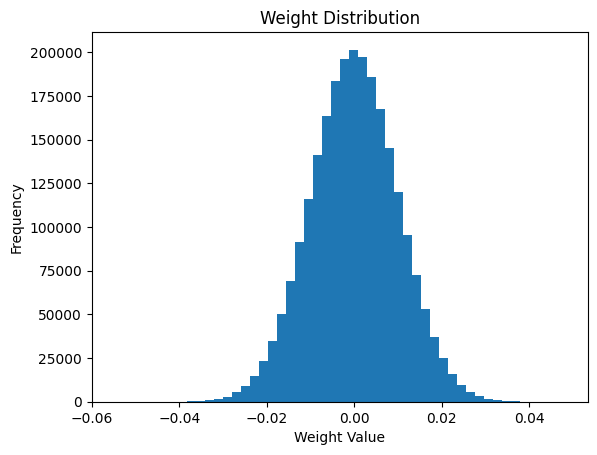

Seq2SeqAttention(
  (encoder): EncoderAttention(
    (embedding): Embedding(104, 128)
    (rnn): GRU(128, 312, batch_first=True, bidirectional=True)
    (fc): Linear(in_features=624, out_features=312, bias=True)
    (dropout): Dropout(p=0.4, inplace=False)
  )
  (decoder): DecoderAttention(
    (attention): Attention(
      (attn_fc): Linear(in_features=936, out_features=312, bias=True)
      (v_fc): Linear(in_features=312, out_features=1, bias=False)
    )
    (embedding): Embedding(104, 128)
    (rnn): GRU(752, 312, batch_first=True)
    (fc_out): Linear(in_features=1064, out_features=104, bias=True)
    (dropout): Dropout(p=0.4, inplace=False)
  )
)

In [15]:
Seq2Seq_model_Attention.apply(init_weights_attention)

plot_weights_initialization(Seq2Seq_model_Attention) #Plot initialization for seeing the distribution of the weihgts

Seq2Seq_model_Attention    

In [16]:
sum_parameters = count_parameters_model(Seq2Seq_model_Attention)
print(f"The total parameters of the model {sum_parameters}")


The total parameters of the model 2450240


#### Optimizer

In [17]:
optimizer = optim.Adam(Seq2Seq_model_Attention.parameters())

/Users/administrador/Library/Python/3.11/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Loss Function

The CrossEntropyLoss function calculates both the log softmax as well as the negative log-likelihood of our predictions.

In [18]:
pad_idx = 0 #Its zero because in the custom_collate, I'm adding 0's for the padding of the sequences
criterion = nn.CrossEntropyLoss(ignore_index = pad_idx)

#### Training Loop

At each iteration:

1. Get the source and target sentences from the batch, and zero the gradients calculated from the last batch.
2. Feed the source and target into the model to get the output.
3. As the loss function only works on 2D inputs with 1D targets, we need to flatten each of them with `.view`.
4. We slice off the first column of the output and target tensors as mentioned above.
5. Calculate the gradients with `loss.backward()`.
6. Clip the gradients to prevent them from exploding (a common issue in RNNs).
7. Update the parameters of our model by doing an optimizer step.
8. Sum the loss value to a running total.

In [19]:
from utils import train_fuction, validation_fuction
import matplotlib.pyplot as plt


In [ ]:
n_epochs = 10
clip = 1.0
teacher_forcing_ratio = 0.5
best_valid_loss = float('inf')
train_losses = []
validation_losses = []

for epoch in tqdm.tqdm(range(n_epochs)):
    train_loss = train_fuction(
        Seq2Seq_model_Attention,
        train_dataset,
        optimizer,
        criterion,
        clip,
        teacher_forcing_ratio,
        device)
    validation_loss = validation_fuction(
        Seq2Seq_model_Attention,
        val_dataset,
        criterion,
        device
    )
    
    train_losses.append(train_loss)
    validation_losses.append(validation_loss)
    
    if validation_loss < best_valid_loss:
        best_valid_loss = validation_loss
        torch.save(Seq2Seq_model_Attention.state_dict(), "tut_attention-model.pt")
    
    print(f"Train Loss: {train_loss:7.3f} - Train PPL: {np.exp(train_loss):7.3f}")
    print(f"Valid Loss: {validation_loss:7.3f} - Valid PPL: {np.exp(validation_loss):7.3f}")

 10%|█         | 1/10 [00:48<07:20, 48.97s/it]

	Train Loss:   3.317 | Train PPL:  27.575
	Valid Loss:   2.555 | Valid PPL:  12.877


 20%|██        | 2/10 [01:28<05:46, 43.31s/it]

	Train Loss:   1.724 | Train PPL:   5.609
	Valid Loss:   1.204 | Valid PPL:   3.332


 30%|███       | 3/10 [02:06<04:46, 40.87s/it]

...

	Train Loss:   0.473 | Train PPL:   1.605
	Valid Loss:   0.514 | Valid PPL:   1.672


 90%|█████████ | 9/10 [05:49<00:37, 37.08s/it]

	Train Loss:   0.478 | Train PPL:   1.612
	Valid Loss:   0.427 | Valid PPL:   1.533


100%|██████████| 10/10 [07:08<00:00, 42.89s/it]

	Train Loss:   0.437 | Train PPL:   1.548
	Valid Loss:   0.423 | Valid PPL:   1.527


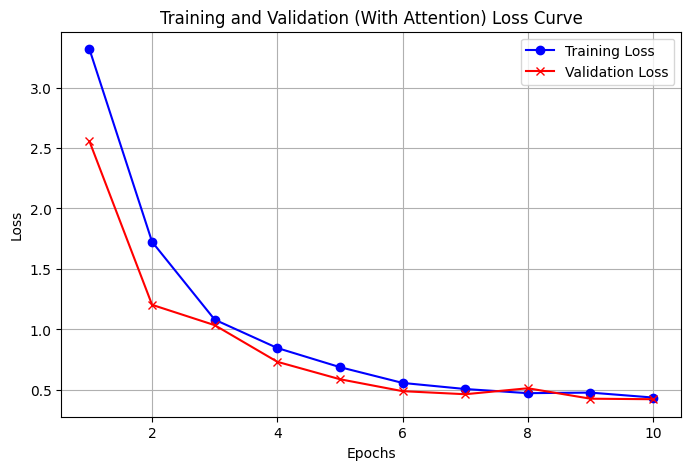

In [22]:
epochs_range = range(1, n_epochs + 1)


plt.figure(figsize=(8, 5))

plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', marker='o')
plt.plot(epochs_range, validation_losses, label='Validation Loss', color='red', marker='x')

plt.title('Training and Validation (With Attention) Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Evaluating the model

In [23]:
from rouge_score import rouge_scorer
from torch.utils.data import DataLoader
from tqdm import tqdm

In [33]:
Seq2Seq_model_Attention.load_state_dict(torch.load("tut_attention-model.pt", map_location=device))
test_loss = validation_fuction(Seq2Seq_model_Attention,
        val_dataset,
        criterion,
        device)


print(f"| Test Loss: {test_loss:.3f} | Test PPL: {np.exp(test_loss):7.3f} |")

| Test Loss: 0.423 | Test PPL:   1.527 |


In [ ]:
import torch

def extract_summary(
    sentence, 
    model, 
    tokenizer,              # Pasas directamente tu instancia de Tokenizer
    device="cpu", 
    max_output_length=50,
    repetition_penalty=1.2
):
    model.eval()
    
    # 1. Codificar usando tu método encode()
    input_ids = tokenizer.encode(sentence)
    
    # Obtener el ID del token especial de fin/inicio (<|endoftext|>)
    eos_idx = tokenizer.text_to_token_ids.get("<|endoftext|>", 0)
    
    # Estructurar la entrada con el token especial al inicio y al final
    src_indexes = [eos_idx] + input_ids + [eos_idx]
    src_tensor = torch.LongTensor(src_indexes).unsqueeze(0).to(device)  # Shape: [1, seq_len]

    # 2. Pasar por el Encoder
    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    # 3. Bucle de generación (Decoder con Penalty)
    inputs = [eos_idx]
    
    for _ in range(max_output_length):
        trg_tensor = torch.LongTensor([inputs[-1]]).to(device)
        
        with torch.no_grad():
            output, hidden, _ = model.decoder(trg_tensor, hidden, encoder_outputs)
            
        logits = output[0]
        
        # Penalización de repetición para evitar bucles infinitos
        for token_id in set(inputs):
            if logits[token_id] < 0:
                logits[token_id] *= repetition_penalty
            else:
                logits[token_id] /= repetition_penalty
                
        pred_token_idx = logits.argmax(0).item()
        
        if pred_token_idx == eos_idx:
            break
            
        inputs.append(pred_token_idx)

    # 4. Decodificar la salida omitiendo el token inicial con tu método decode()
    generated_ids = inputs[1:]
    return tokenizer.decode(generated_ids)

### Without Attention

In [32]:
frases = [
    "Schedule a meeting with Sarah by Friday and remember to run the database backup",
    "Buy milk, eggs, and bread from the grocery store tomorrow morning"
]

for texto in frases:
    tokens = extract_summary(
        sentence=texto,
        model=Seq2Seq_model_Attention,
        src_nlp=tokenizer,                      
        src_vocab=tokenizer.text_to_token_ids,  
        trg_vocab=tokenizer.text_to_token_ids,  
        sos_token="<unk>",                      
        eos_token="<|endoftext|>",              
        device=device
    )
    print(f"Entrada: {texto}")
    print(f"Salida:  {' '.join(tokens)}\n")

Entrada: Schedule a meeting with Sarah by Friday and remember to run the database backup
Salida:  . schedule meeting with sarah by friday | 2 . run the database backup on tuesday pm run the database backup backup friday pm run run the database backup on tuesday pm run the database backup backup friday pm run the database backup backup on tuesday pm run the database

Entrada: Buy milk, eggs, and bread from the grocery store tomorrow morning
Salida:  . buy the repository | 2 . clean the client repository at . update the repository repository at midnight . update the repository at midnight . update the repository at midnight . update the repository at midnight . update the repository at midnight . update the repository at midnight .



In [25]:
predictions = []
references = []

for batch in test_loader:
    # 1. Extraer los tensores del batch
    input_ids_batch = batch['tokenized_input']  # O la clave que contenga las entradas
    target_ids_batch = batch['label']       # O la clave que contenga los targets
    
    # 2. Iterar sobre cada elemento del batch
    for input_ids, target_ids in zip(input_ids_batch, target_ids_batch):
        
        # Convertir Tensor a lista y decodificar a String
        if isinstance(input_ids, torch.Tensor):
            input_text = tokenizer.decode(input_ids.tolist())
        else:
            input_text = input_ids

        if isinstance(target_ids, torch.Tensor):
            target_text = tokenizer.decode(target_ids.tolist())
        else:
            target_text = target_ids

        # 3. Inferencia con extract_summary
        tokens_pred = extract_summary(
            sentence=input_text,
            model=Seq2Seq_model,
            src_nlp=tokenizer,
            src_vocab=tokenizer.text_to_token_ids,
            trg_vocab=tokenizer.text_to_token_ids,
            sos_token="<unk>",
            eos_token="<|endoftext|>",
            device=device
        )
        
        predictions.append(" ".join(tokens_pred))
        references.append(target_text)

In [ ]:
import evaluate

rouge = evaluate.load('rouge')
bleu = evaluate.load('bleu')


rouge_results = rouge.compute(
    predictions=predictions, 
    references=references,
    use_stemmer=True
)


bleu_results = bleu.compute(
    predictions=predictions, 
    references=references
)

In [28]:
print("--- Rogue Results---")
rouge_results

--- Rogue Results---


{'rouge1': 0.376813055221071,
 'rouge2': 0.22634177519722903,
 'rougeL': 0.3640130993844639,
 'rougeLsum': 0.36413509606233363}

In [29]:
print("\n--- Blue Results ---")
bleu_results


--- Blue Results ---


{'bleu': 0.21510804279655596,
 'precisions': [0.3405982905982906,
  0.24410551134689065,
  0.18711843711843712,
  0.13762266540044318],
 'brevity_penalty': 1.0,
 'length_ratio': 1.5135834411384217,
 'translation_length': 14040,
 'reference_length': 9276}